In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 📊 Étape 4 : Visualisation Multidimensionnelle (Squelette Étudiant)

Cette étape correspond au quatrième chapitre du cours. L'objectif est de concevoir des représentations visuelles premium pour identifier des tendances et insights clés à l'aide de votre package personnalisé de tracé `src.utils_viz`.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
# from src import data_clean as dc
# from src import utils_viz as uv

# Activation du style premium personnalisé (light ou dark)
# uv.set_custom_style(theme='light')
%matplotlib inline
print("Librairies de visualisation prêtes !")

Librairies de visualisation prêtes !


### 2. Chargement du dataset enrichi

In [3]:
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')

df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,OpSys,Price,Res_Width,...,has_ssd,has_hdd,has_flash,has_hybrid,total_memory_gb,gpu_brand,has_intel_gpu,has_nvidia_gpu,has_amd_gpu,weight_kg
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,macOS,71378.6832,2560,...,1,0,0,0,128.0,Intel,1,0,0,1.37
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,macOS,47895.5232,1440,...,0,0,1,0,128.0,Intel,1,0,0,1.34
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,No OS,30636.0000,1920,...,1,0,0,0,256.0,Intel,1,0,0,1.86
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,macOS,135195.3360,2880,...,1,0,0,0,512.0,AMD,0,0,1,1.83
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,macOS,96095.8080,2560,...,1,0,0,0,256.0,Intel,1,0,0,1.37


### 3. Tracés et analyses graphiques

#### A. Distribution des prix

['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'OpSys', 'Price', 'Res_Width', 'Res_Height', 'Is_IPS', 'Cpu_Gamme', 'Cpu_Frequence_GHz', 'has_ssd', 'has_hdd', 'has_flash', 'has_hybrid', 'total_memory_gb', 'gpu_brand', 'has_intel_gpu', 'has_nvidia_gpu', 'has_amd_gpu', 'weight_kg']


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,OpSys,Price,Res_Width,...,has_ssd,has_hdd,has_flash,has_hybrid,total_memory_gb,gpu_brand,has_intel_gpu,has_nvidia_gpu,has_amd_gpu,weight_kg
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,macOS,71378.6832,2560,...,1,0,0,0,128.0,Intel,1,0,0,1.37
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,macOS,47895.5232,1440,...,0,0,1,0,128.0,Intel,1,0,0,1.34
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,No OS,30636.0000,1920,...,1,0,0,0,256.0,Intel,1,0,0,1.86
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,macOS,135195.3360,2880,...,1,0,0,0,512.0,AMD,0,0,1,1.83
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,macOS,96095.8080,2560,...,1,0,0,0,256.0,Intel,1,0,0,1.37


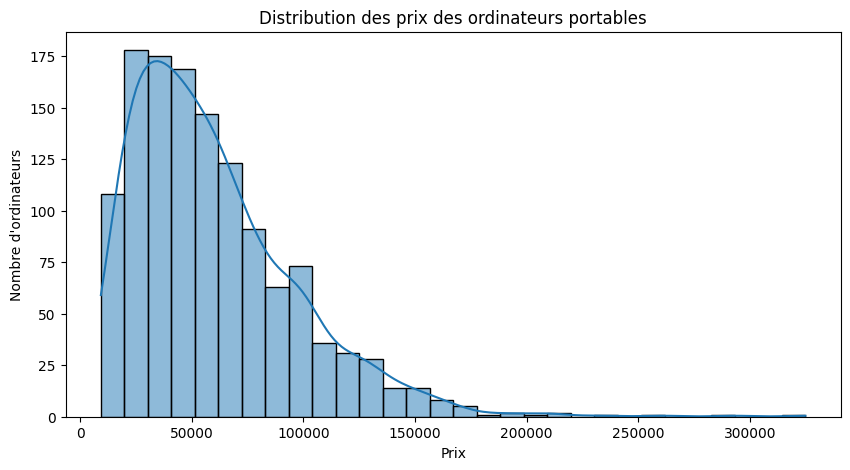

In [4]:
# vérification des colonnes
print(df.columns.tolist())
display(df.head())

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="Price", bins=30, kde=True)

plt.title("Distribution des prix des ordinateurs portables")
plt.xlabel("Prix")
plt.ylabel("Nombre d'ordinateurs")

plt.show()

#### B. Répartition des marques

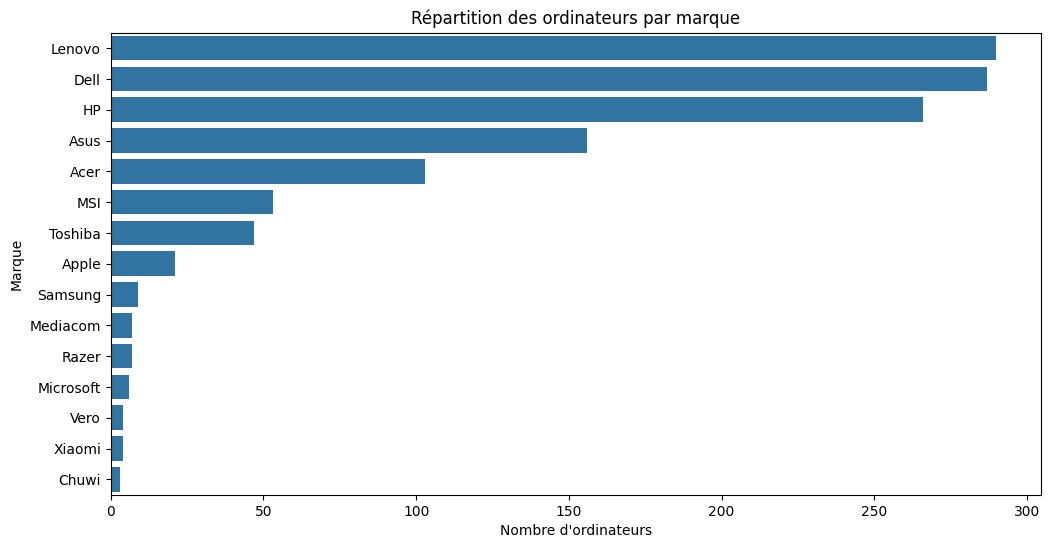

In [5]:
plt.figure(figsize=(12, 6))

company_counts = df["Company"].value_counts().head(15)

sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)

plt.title("Répartition des ordinateurs par marque")
plt.xlabel("Nombre d'ordinateurs")
plt.ylabel("Marque")

plt.show()

#### C. Répartition des types d'ordinateurs

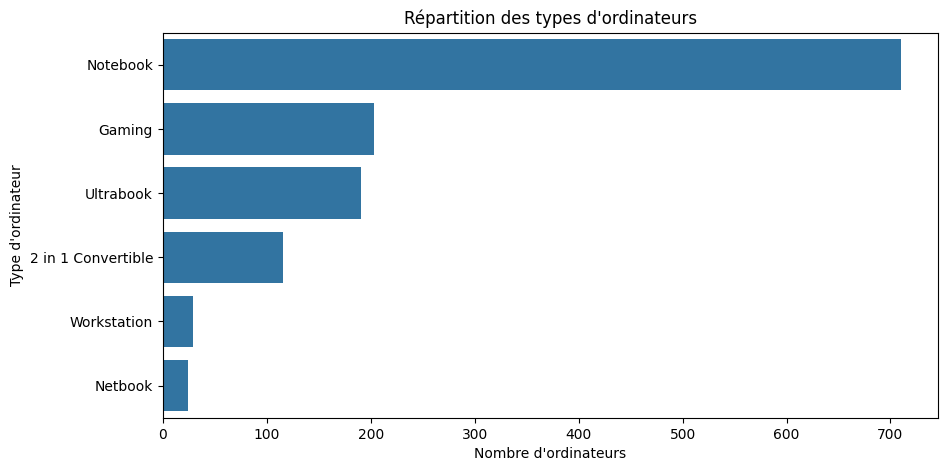

In [6]:
type_counts = df["TypeName"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=type_counts.values,
    y=type_counts.index
)

plt.title("Répartition des types d'ordinateurs")
plt.xlabel("Nombre d'ordinateurs")
plt.ylabel("Type d'ordinateur")

plt.show()

#### D. Matrice de corrélation

Valeurs manquantes après conversion numérique :


Price                0
Inches               1
Res_Width            0
Res_Height           0
Cpu_Frequence_GHz    0
total_memory_gb      0
weight_kg            0
has_ssd              0
has_hdd              0
has_flash            0
has_hybrid           0
has_intel_gpu        0
has_nvidia_gpu       0
has_amd_gpu          0
dtype: int64

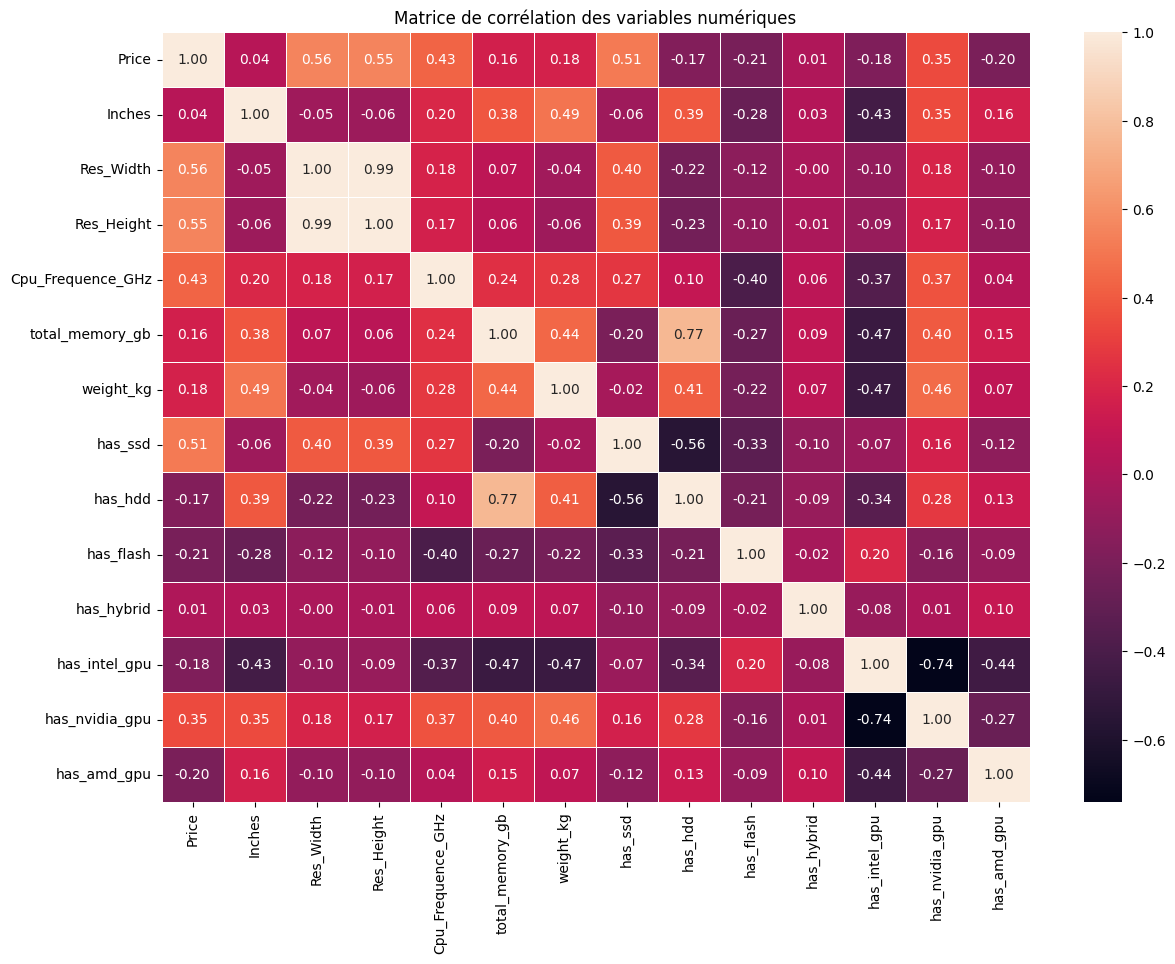

In [7]:
selected_numeric_columns = [
    "Price",
    "Inches",
    "Res_Width",
    "Res_Height",
    "Cpu_Frequence_GHz",
    "total_memory_gb",
    "weight_kg",
    "has_ssd",
    "has_hdd",
    "has_flash",
    "has_hybrid",
    "has_intel_gpu",
    "has_nvidia_gpu",
    "has_amd_gpu"
]

numeric_df = df[selected_numeric_columns].copy()

# Conversion sécurisée en numérique
for col in selected_numeric_columns:
    numeric_df[col] = pd.to_numeric(numeric_df[col], errors="coerce")

print("Valeurs manquantes après conversion numérique :")
display(numeric_df.isnull().sum())

# Matrice de corrélation
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables numériques")
plt.show()

#### E. Prix moyen par marque


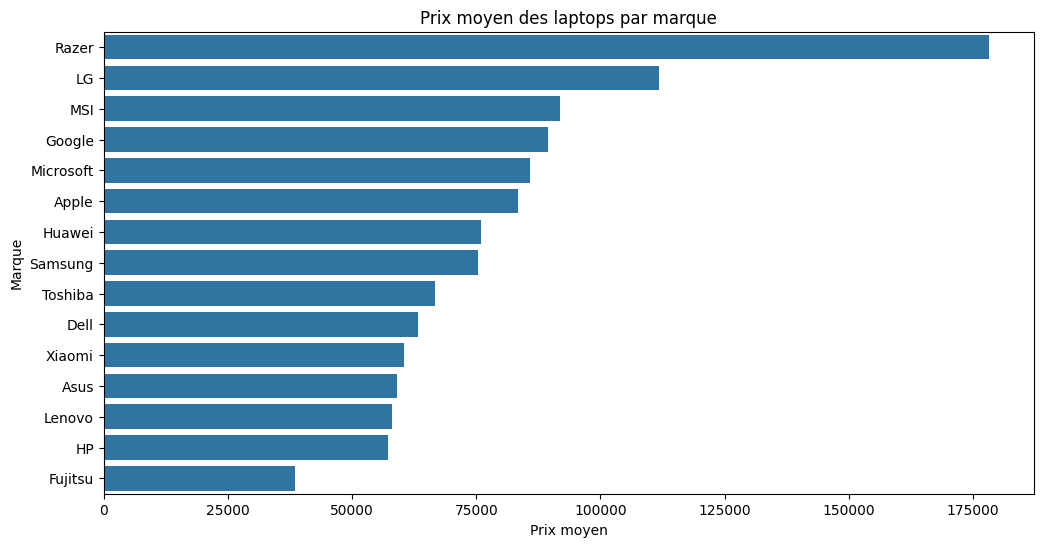

In [8]:
price_by_company = (
    df.groupby("Company")["Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=price_by_company.values, y=price_by_company.index)

plt.title("Prix moyen des laptops par marque")
plt.xlabel("Prix moyen")
plt.ylabel("Marque")

plt.show()

#### F. Relation poids / prix

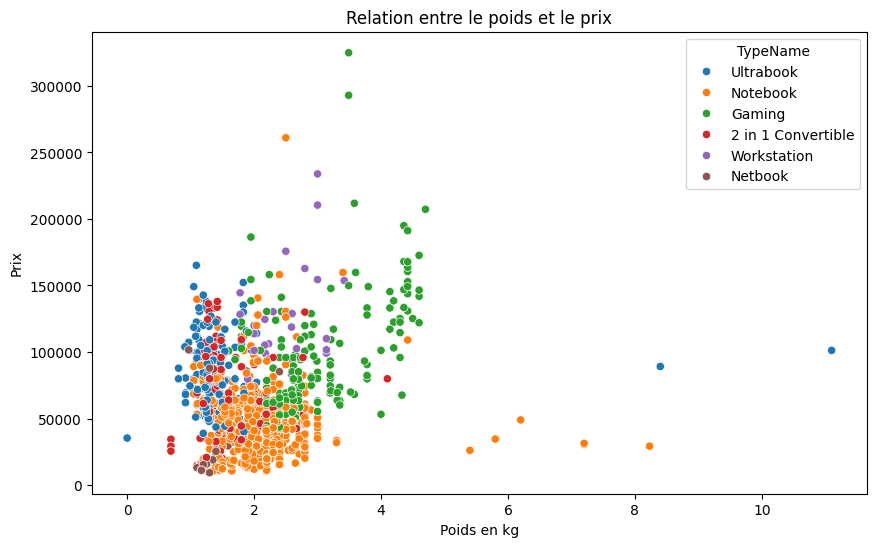

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="weight_kg", y="Price", hue="TypeName")
plt.title("Relation entre le poids et le prix")
plt.xlabel("Poids en kg")
plt.ylabel("Prix")
plt.show()

#### G. Relation stockage / prix

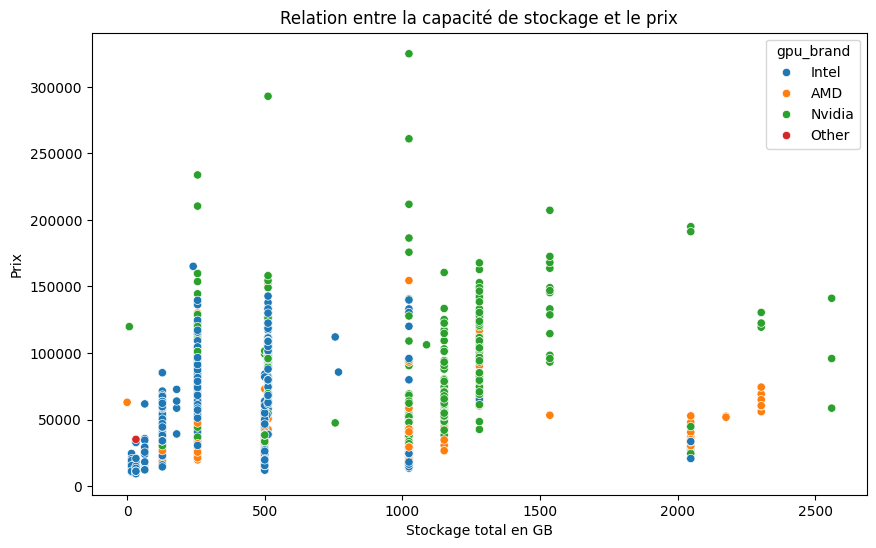

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="total_memory_gb", y="Price", hue="gpu_brand")

plt.title("Relation entre la capacité de stockage et le prix")
plt.xlabel("Stockage total en GB")
plt.ylabel("Prix")

plt.show()